# ARESD - Prédictions des émissions carbones

## Modules

In [6]:
# Calcul sur des large set de données
import numpy  as np

# Lecture/Ecriture des Données
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Visulisation Arbre
from graphviz import Digraph

# Graine Aléatoire
import time

# Foret Aléatoires plus rapides
import concurrent
import multiprocessing

# Indices de type
from typing import *

# Sortie
import os
os.makedirs("graphes", exist_ok=True)

## Préparation des données

In [19]:
def encode_label(vfeature: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Encode une liste de catégories

    Parameters:
    - vfeature (np.ndarray): Liste de catégories

    Returns:
    - encoded_labels (np.ndarray): Liste de catégorie codée en entiers
    - reverser (np.ndarray): Tableau de correspondance qui permet d'inverser le processus
    """
    reverser, encoded_labels = np.unique(vfeature, return_inverse=True)
    return encoded_labels, reverser

def encode_label_manuel(vfeature: np.ndarray, custom_order: list) -> Tuple[np.ndarray, np.ndarray]:
    """
    Encode une liste de catégories

    Parameters:
    - vfeature (np.ndarray): Liste de catégories
    - custom_order (list): Correspondance souhaitée

    Returns:
    - encoded_labels (np.ndarray): Liste de catégorie codée en entiers
    - reverser (np.ndarray): Tableau de correspondance qui permet d'inverser le processus
    """
    encoded_labels = np.array([custom_order.index(feature) for feature in vfeature])
    reverser = np.array(custom_order)
    return encoded_labels, reverser

def normalize(data: np.ndarray):
    """
    Normalise une colonne

    Parameters:
    - data (np.ndarray): Données
    Returns:
    - ncol (np.ndarray): Valeur normalisés

    Raises:
    - AssertionError: Si data n'est pas un tableau panda
    """
    assert(type(data) == np.ndarray)

    min_val = np.min(data)
    max_val = np.max(data)
    return (data - min_val) / (max_val - min_val)


def discretize(data: np.ndarray, fmin: float, fmax: float, step: float) -> np.ndarray:
    """
    Discrétise une colonne

    Parameters:
    - data (np.ndarray): Données
    - fmin (float): Borne inférieure
    - fmax (float): Borne supérieur (incluse)
    - step (float): Pas pour la discrétisation

    Returns:
    - dcol (np.ndarray): Valeur discrétisées à la valeur la plus proche supérieure

    Raises:
    - AssertionError: Si data n'est pas un tableau panda
    """
    assert(type(data) == np.ndarray)

    fourchette = np.arange(fmin, fmax+step, step)
    return fourchette[np.digitize(np.clip(data, fmin, fmax), fourchette, right=True)]


def load_data(path: str, entrainement: bool = True) -> pd.DataFrame:
    """
    Charge les données et les prépare

    Parameters:
    - path (str): Chemin du fichier
    - entrainement (bool): Mode entrainement effectue les transformation sur les variables cibles

    Returns:
    - data (pd.Dataframe): Tableau panda avec les données chargées avec variables synthétiques
    """
    data = pd.read_csv(path)

    # Jourdumois semble rarement fonctionner mieux que les autres variables de temps
    data["DateTime"]   = pd.to_datetime(data["DateTime"])
    data["JourduMois"] = data["DateTime"].dt.day

    # Le groupement des vacances permet toujours une meilleure performance selon les tests
    data["Vacance"]    = (data["VacancesZoneA"]+0) + (data["VacancesZoneB"]+0) + (data["VacancesZoneC"]+0)

    # Les pas sont obtenus en testant plusieurs niveaux de discrétisation et en prenant les meilleur selon la performance avec K-Fold
    data["dPDA"]   = discretize(data["PositionDansAnnee"].to_numpy() ,   0,   1, .25)
    data["dHeure"] = discretize(data["DemiHeure"].to_numpy()         ,   0,  48,   2)
    data["dTemp"]  = discretize(data["Temperature"].to_numpy()       , -10,  50,   5)
    data["dNebu"]  = discretize(data["Nebulosity"].to_numpy()        ,   0, 100,  10)
    data["dHumi"]  = discretize(data["Humidity"].to_numpy()          ,   0, 100,  10)
    data["dWind"]  = discretize(data["WindSpeed"].to_numpy()         ,   0,  10,  .2)
    data["dRain"]  = discretize(data["Precipitation"].to_numpy()     ,   0,   5,  .1)

    # Numérisation des valeurs discrètes
    data["iJour"] = encode_label_manuel(data["Jour"], ["lundi", "mardi", "mercredi", "jeudi", "vendredi", "samedi", "dimanche"])[0]
    data["iMois"] = encode_label_manuel(data["Mois"], [
        "janvier",
        "février",
        "mars",
        "avril",
        "mai",
        "juin",
        "juillet",
        "août",
        "septembre",
        "octobre",
        "novembre",
        "décembre"
    ])[0]

    data["iTJF"] = encode_label(data["JourFerieType"])[0]

    if entrainement:
        data["iMPE"] = encode_label_manuel(data["MixProdElec"], ["Decarbonne", "Normal", "Carbonne"])[0]

    # Normalization
    if entrainement:
        data["nCO2"]  = normalize(data["EmissionCO2"].to_numpy())
    data["nHumi"] = normalize(data["Humidity"].to_numpy())
    data["nNebu"] = normalize(data["Nebulosity"].to_numpy())
    data["nRain"] = normalize(data["Precipitation"].to_numpy())

    return data

def k_fold(data: pd.DataFrame, k: int, i: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Donne les set de données pour k-fold de la i-ème itération (commence à 0)

    Parameters:
    - data (pd.DataFrame): Données à découper
    - k (int): Nombre de partitions
    - i (int): i-ème partition (commence à 0)

    Returns:
    - Tuple[pd.DataFrame, pd.DataFrame]: Données d'apprentissage et de test

    Raises:
    - AssertionError: Si i est supérieur ou égal à k
    """
    assert(i < k)

    n = len(data)
    fold_size = n // k

    start_index = i * fold_size
    end_index = start_index + fold_size if i < k - 1 else n

    test_indices = list(range(start_index, end_index))
    train_indices = list(set(range(n)) - set(test_indices))

    train_data = data.iloc[train_indices]
    test_data = data.iloc[test_indices]

    return train_data, test_data

## Visualisation

COV Humi-Rain: 0.004340582344784287
COV Nebu-Rain: 0.006430781543108087
COV Nebu-Humi: 0.016329786809603074
COV JourduMois: 0.0004626532571805271
COV dPDA: 0.003527376564482078
COV Annee: -0.0074236381660887606
COV Mois: 0.0038660203084466744
COV dHeure: 0.004555788267220936
COV Jour: -0.009482302163994824
COV JourFerie: -0.0033619176004108593
COV JourFerieType: 0.0006185763432413392
COV Vacance: -0.009490807794900694
COV dTemp: -0.01167463281269443
COV dNebu: 0.0030388281274586985
COV dHumi: 0.0053773767246017585
COV dWind: -0.0021781662866093236
COV dRain: -0.0011074515262778472


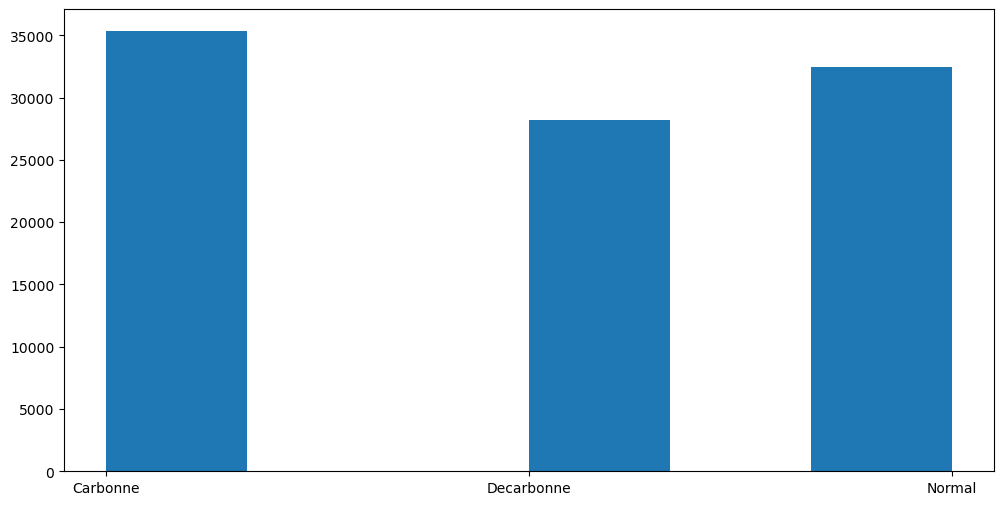

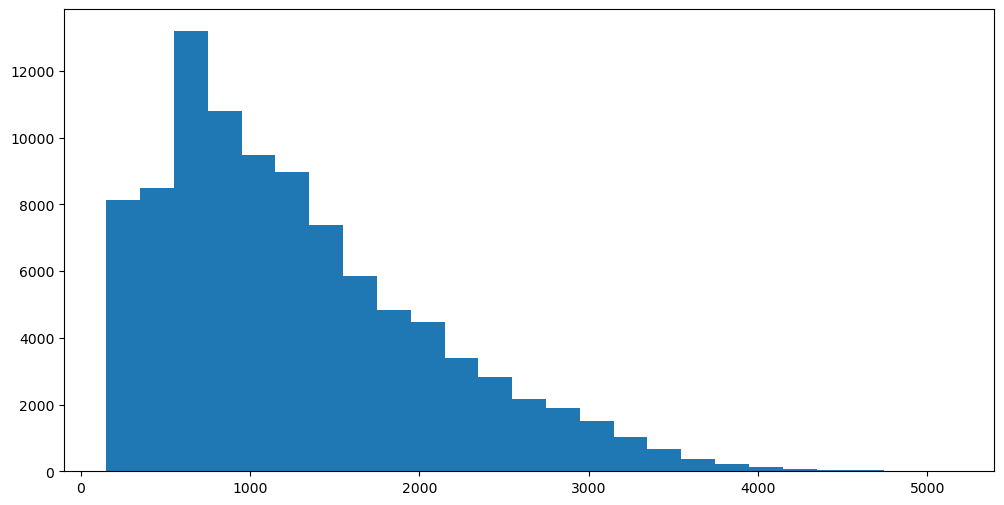

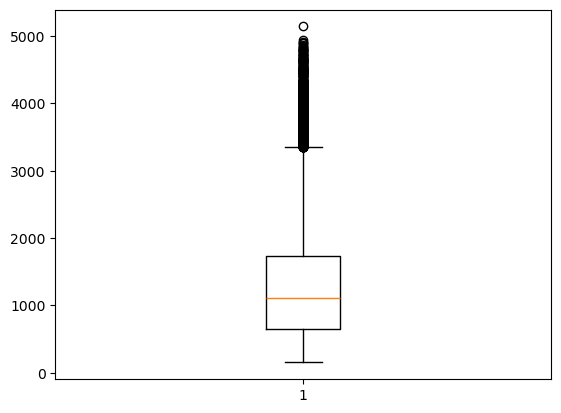

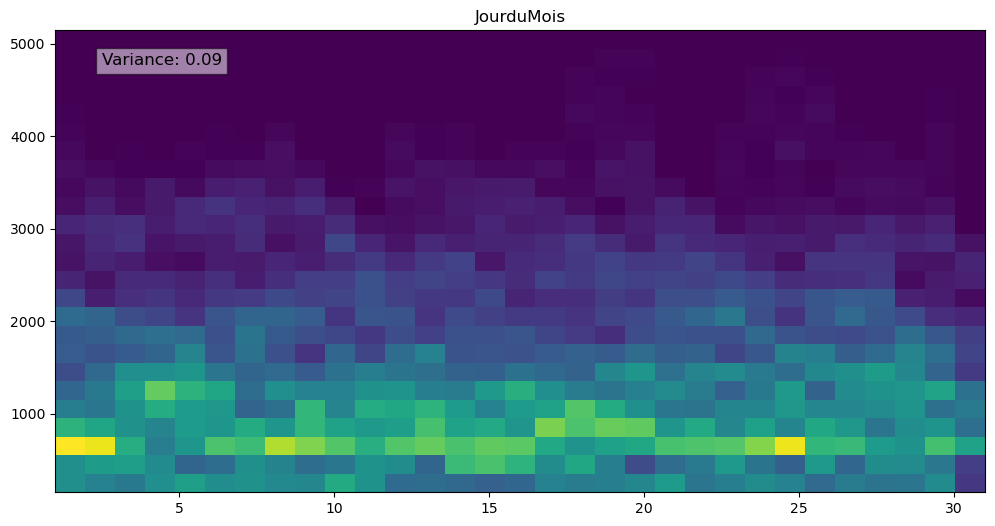

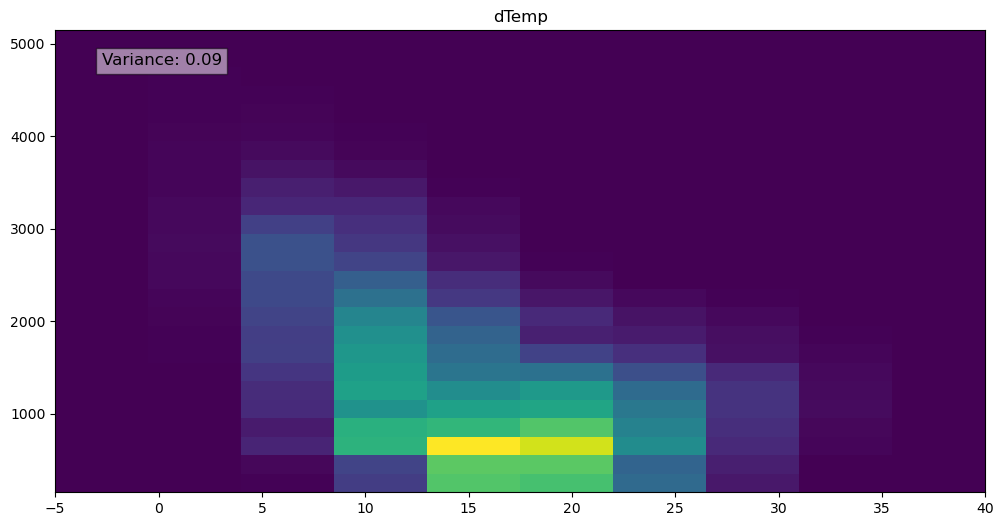

In [8]:
def diagnostic_complet():
    """
    Affiche les covariances et sauvegardes tout les graphiques sur les variables
    """

    data = load_data("train.csv")
    colonnes = ["JourduMois", "dPDA", "Annee", "Mois", "dHeure", "Jour", "JourFerie", "JourFerieType", "Vacance", "dTemp", "dNebu", "dHumi", "dWind", "dRain"]

    # Box Plot Emissions
    plt.boxplot(data["EmissionCO2"])
    plt.savefig(f"graphes/boxplot_co2.png")
    plt.close()

    # Histogramme Mix Prod Elec et Emissions
    mpe_reverser = np.array(["Decarbonne", "Normal", "Carbonne"])
    fig, ax = plt.subplots(figsize=(12, 6))
    plt.hist(data["iMPE"], bins=len(mpe_reverser)*2)
    plt.xticks(np.unique(data["iMPE"]), mpe_reverser)
    plt.savefig(f"graphes/hist_mpe.png")
    plt.close()

    fig, ax = plt.subplots(figsize=(12, 6))
    plt.hist(data["EmissionCO2"], bins=25)
    plt.savefig(f"graphes/hist_co2.png")
    plt.close()

    print(f"COV Humi-Rain: {np.cov(data['nHumi'], data['nRain'])[0][1]}")
    print(f"COV Nebu-Rain: {np.cov(data['nNebu'], data['nRain'])[0][1]}")
    print(f"COV Nebu-Humi: {np.cov(data['nNebu'], data['nHumi'])[0][1]}")

    for colonne in colonnes:
        # Valeur numérique
        if data[colonne].to_numpy().dtype not in [object, bool]:
            normalized = normalize(data[colonne].to_numpy())

            fig, ax = plt.subplots(figsize=(12, 6))

            if colonne == "Annee":
                plt.hist2d(data[colonne], data["EmissionCO2"], bins=[len(np.unique(data[colonne])) + 2, 25])
            else:
                plt.hist2d(data[colonne], data["EmissionCO2"], bins=[len(np.unique(data[colonne])), 25])
            print(f"COV {colonne}: {np.cov(data['nCO2'], normalized)[0][1]}")

            plt.text(0.05, 0.95, f'Variance: {np.var(normalized):.2f}', transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
            plt.title(colonne)
            plt.savefig(f"graphes/hist_{colonne}.png")
            plt.close()

            plt.boxplot(data[colonne])
            plt.title(colonne)
            plt.savefig(f"graphes/boxplot_{colonne}.png")
            plt.close()

        else:
            if colonne == "Jour":
                encoded = data["iJour"].to_numpy()
                reverser = np.array(["lundi", "mardi", "mercredi", "jeudi", "vendredi", "samedi", "dimanche"])
            elif colonne == "Mois":
                encoded = data["iMois"].to_numpy()
                reverser = np.array([
                    "janvier",
                    "février",
                    "mars",
                    "avril",
                    "mai",
                    "juin",
                    "juillet",
                    "août",
                    "septembre",
                    "octobre",
                    "novembre",
                    "décembre"
                ])
            elif colonne == "JourFerieType":
                encoded = data["iTJF"].to_numpy()
                reverser = np.unique(data["JourFerieType"])
            else:
                encoded, reverser = encode_label(data[colonne])
                encoded = encoded
            print(f"COV {colonne}: {np.cov(data['nCO2'], normalize(encoded))[0][1]}")

            fig, ax = plt.subplots(figsize=(12, 6))
            plt.hist2d(encoded, data["EmissionCO2"], bins=[len(reverser)*2, 25])
            plt.text(0.05, 0.95, f'Variance: {np.var(normalized):.2f}', transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
            plt.xticks(np.unique(encoded), reverser)
            plt.title(colonne)
            plt.savefig(f"graphes/hist_{colonne}.png")
            plt.close()

def presentation():
    data = load_data("train.csv")

    mpe_reverser = np.unique(data["MixProdElec"])
    fig, ax = plt.subplots(figsize=(12, 6))
    plt.hist(data["iMPE"], bins=len(mpe_reverser)*2)
    plt.xticks(np.unique(data["iMPE"]), mpe_reverser)
    plt.show()
    plt.close()

    fig, ax = plt.subplots(figsize=(12, 6))
    plt.hist(data["EmissionCO2"], bins=25)
    plt.show()
    plt.close()

    plt.boxplot(data["EmissionCO2"])
    plt.show()
    plt.close()

    jdm_normalized = normalize(data["JourduMois"].to_numpy())
    fig, ax = plt.subplots(figsize=(12, 6))
    plt.hist2d(data["JourduMois"], data["EmissionCO2"], bins=[len(np.unique(data["JourduMois"])), 25])
    plt.text(0.05, 0.95, f'Variance: {np.var(jdm_normalized):.2f}', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
    plt.title("JourduMois")
    plt.show()
    plt.close()

    temp_normalized = normalize(data["dTemp"].to_numpy())
    fig, ax = plt.subplots(figsize=(12, 6))
    plt.hist2d(data["dTemp"], data["EmissionCO2"], bins=[len(np.unique(data["dTemp"])), 25])
    plt.text(0.05, 0.95, f'Variance: {np.var(jdm_normalized):.2f}', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
    plt.title("dTemp")
    plt.show()
    plt.close()

    # vaca_normalized = normalize(data["Vacance"].to_numpy())
    # fig, ax = plt.subplots(figsize=(12, 6))
    # plt.hist2d(data["Vacance"], data["EmissionCO2"], bins=[len(np.unique(data["Vacance"])), 25])
    # plt.text(0.05, 0.95, f'Variance: {np.var(jdm_normalized):.2f}', transform=ax.transAxes, fontsize=12,
    #     verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
    # plt.title("Vacance")
    # plt.show()
    # plt.close()

# Affiche les covariances
diagnostic_complet()

# Affiche les graphiques
presentation()

## Implémentation de l'arbre

In [9]:
## Prise de https://github.com/JuvignyEnsta/decisiontree

def gini_impurity(Y: np.ndarray) -> float:
    """
    Calcule l'indice de Gini pour une liste de catégorie donnée

    Parameters:
    - Y (np.ndarray): Liste de catégorie (ici ce sera la variable cible)

    Returns:
    - gini (float): L'impurité de Gini
    """
    _, occurence = np.unique(Y, return_counts=True)
    return 1.0 - np.sum((occurence / len(Y)) ** 2)


def split_data(X: np.ndarray, Y: np.ndarray, ifeature: int, threshold: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Sépare les variables et la variable cible selon une catégorie et un seuil

    Parameters:
    - X (np.ndarray): Matrice de données
    - Y (np.ndarray): Liste de variable à prédire
    - ifeature (int): Index de la catégorie dans X
    - threshold (float): Seuil de séparation

    Returns:
    - x_left  (np.ndarray): Données strictement inférieure au seuil
    - y_left  (np.ndarray): Variable cible correspondant à left_data
    - x_right (np.ndarray): Données supérieur au seuil
    - y_right (np.ndarray): Variable cible correspondant à right_data
    """
    left_mask = X[:, ifeature] < threshold
    right_mask = ~left_mask
    return X[left_mask], Y[left_mask], X[right_mask], Y[right_mask]


def find_best_split(X: np.ndarray, Y: np.ndarray) -> Tuple[int, float]:
    """
    Cherche la meilleure catégorie sur laquelle faire la séparation

    Parameters:
    - X (np.ndarray): Matrice de données
    - Y (np.ndarray): Liste de variable à prédire

    Returns:
    - best_feature (int): Index de la catégorie dans X avec le meilleur indice de Gini
    - best_threshold (float): Seuil de séparation avec le meillur indice de Gini
    """
    best_feature, best_threshold, best_gini = None, None, float('inf')

    # Simple méthode itérative pour trouver le meilleur
    for ifeature in range(X.shape[1]):
        thresholds = np.unique(X[:, ifeature])
        for threshold in thresholds:
            _, y_left, _, y_right = split_data(X, Y, ifeature, threshold)
            if (len(y_left) * len(y_right)) == 0:
                continue
            gini = (len(y_left) * gini_impurity(y_left) + len(y_right) * gini_impurity(y_right)) / len(Y)
            if gini < best_gini:
                best_feature, best_threshold, best_gini = ifeature, threshold, gini
    return best_feature, best_threshold

def build_tree(X: np.ndarray, Y: np.ndarray, max_depth: int, min_samples_split: int, depth: int = 0) -> Dict[str, Union[int, float, Dict[str, Any]]]:
    """
    Construit un arbre de décision

    Parameters:
    - X (np.ndarray): Matrices de données
    - Y (np.ndarray): Variable à prédire encodé en entier
    - max_depth (int): Profondeur maximum
    - min_samples_split (int): Seuil d'échantillon pour constituer un noeud
    - depth (int): Ne pas spécifier variable utilisée pour la récursion

    Returns:
    - tree (Dict[str, Union[int, float, Dict[str, Any]]]): Arbre
    """
    if depth == max_depth or len(Y) < min_samples_split or gini_impurity(Y) == 0:
        return {'prediction': np.argmax(np.bincount(Y))}

    feature, threshold = find_best_split(X, Y)

    if feature is None:
        return {"prediction": np.argmax(np.bincount(Y))}

    x_left, y_left, x_right, y_right = split_data(X, Y, feature, threshold)

    return {
        "feature": feature,
        "threshold": threshold,
        "left": build_tree(x_left, y_left, max_depth, min_samples_split, depth + 1),
        "right": build_tree(x_right, y_right, max_depth, min_samples_split, depth + 1)
    }

def predict_sample(tree: dict, sample: np.ndarray) -> int:
    """
    Predire pour un X donné

    Parameters:
    - tree (dict): Arbre de décision
    - sample (np.ndarray): échantillon de donnée

    Returns:
    - y_pred (int): Y prédit sous forme entier
    """
    cursor = tree

    # Tant que pas feuille
    while "prediction" not in cursor:
        if sample[cursor["feature"]] < cursor["threshold"]:
            cursor = cursor["left"]
        else:
            cursor = cursor["right"]
    return cursor["prediction"]

# Enveloppe

In [13]:
class DecisionTree:
    """
    Classe pour faciliter la gestion d'un arbre de décision

    Attributes:
    - max_depth (int): Profondeur maximum
    - min_samples_split (int): Seuil d'échantillon pour constituer un noeud
    - model (dict or None): Arbre
    """

    def __init__(self, max_depth: Union[int, np.int64], min_samples_split: Union[int, np.int64]):
        """
        Initialise l'arbre

        Parameters:
        - max_depth (int): Profondeur maximum
        - min_samples_split (int): Seuil d'échantillon pour constituer un noeud

        Raises:
        - AssertionError: Si les arguments ne sont pas des entiers
        """
        assert(type(max_depth) in [int, np.int64])
        assert(type(min_samples_split) in [int, np.int64])

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.model = None

    def train(self, x_train: np.ndarray, y_train: np.ndarray):
        """
        Entraine l'arbre sur les données

        Parameters:
        - x_train (np.ndarray): Matrice de données
        - y_train (np.ndarray): Variable cible

        Raises:
        - AssertionError: Si les arguments ne sont pas des tableaux n-dimensionnels numpy
        """
        assert(type(x_train) == np.ndarray)
        assert(type(y_train) == np.ndarray)

        self.model = build_tree(x_train, y_train, self.max_depth, self.min_samples_split)

    def predict(self, x_test: np.ndarray) -> np.ndarray:
        """
        Prédiction pour une liste d'échantillon

        Parameters:
        - x_test (np.ndarray): Matrice de données

        Returns:
        - y_pred (np.ndarray): Liste des prédictions

        Raises:
        - AssertionError: Si x_test n'est pas un tableau n-dimensionnel numpy
        """
        assert(type(x_test) == np.ndarray)

        return np.array([predict_sample(self.model, x) for x in x_test])

## Foret Aléatoire

In [17]:
class RandomForest:
    """
    Foret Aléatoire

    Attributes:
    - max_features (int): Maximum de variable à prendre pour chaque arbre
    - size (int): Nombre d'arbres
    - max_depth (int): Profondeur maximale
    - min_samples_split (int): Seuil d'échantillon pour constituer un noeud
    - models (List[DecisionTree]): Liste d'arbre
    - vfeature_indices (List[List[int]]): Liste de la liste des variable pour chaque arbre
    """

    def __init__(self, max_features: Union[int, np.int64], size: Union[int, np.int64], max_depth: Union[int, np.int64], min_samples_split: Union[int, np.int64]):
        """
        Initialise la foret

        Parameters:
        - max_features (int): Maximum de variable à prendre pour chaque arbre
        - size (int): Nombre d'arbres
        - max_depth (int): Profondeur maximale
        - min_samples_split (int): Seuil d'échantillon pour constituer un noeud

        Raises:
        - AssertionError: Si les arguments ne sont pas des entiers
        """
        assert(type(size) in [int, np.int64])
        assert(type(max_features) in [int, np.int64])
        assert(type(max_depth) in [int, np.int64])
        assert(type(min_samples_split) in [int, np.int64])

        self.max_features = max_features
        self.size = size
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.models = [None for _ in range(self.size)]
        self.vfeature_indices = [None for _ in range(self.size)]

    def graphe_(self, features: List[str], vfeature_indices: List[int], tree: Dict[str, Union[int, float, Dict[str, Any]]], depth: int = 0, graph: Digraph = None, split_index: int = 0) -> Digraph:
        """
        Retourne un graphe graphviz pour etre visualisé

        Parameters:
        - features (list): Liste globale des noms de variables utilisé dans l'arbre
        - vfeature_indices (list): Liste des indices des features utilisés pour un arbre
        - tree (graphviz.Digraph): Arbre

        Returns:
        - graph (graphviz.Digraph): Graphe
        """
        if graph is None:
            graph = Digraph(comment=f"Arbre de Décision N°{split_index}")

        if "prediction" in tree:
            graph.node(f"{depth}_Prediction", label=f"Prediction: {tree['prediction']}")
            return graph

        feature_name = features[vfeature_indices[tree['feature']]]
        threshold = tree['threshold']
        split_label = f"{feature_name}\nSeuil: {threshold}\nSplit n°{split_index}"
        graph.node(f"{depth}_{split_index}", label=split_label)

        if 'left' in tree and 'feature' in tree['left']:
            graph = self.graphe_(features, vfeature_indices, tree['left'], depth + 1, graph, split_index=2*split_index+1)
            graph.edge(f"{depth}_{split_index}", f"{depth + 1}_{2*split_index+1}")

        if 'right' in tree and 'feature' in tree['right']:
            graph = self.graphe_(features, vfeature_indices, tree['right'], depth + 1, graph, split_index=2*split_index+2)
            graph.edge(f"{depth}_{split_index}", f"{depth + 1}_{2*split_index+2}")

        return graph

    def graphe(self, features: List[str], vfeature_indices: List[int], itree: int):
        """
        Retourne un graphe graphviz pour etre visualisé

        Parameters:
        - features (list): Liste globale des noms de variables utilisé dans l'arbre
        - vfeature_indices (list): Liste des indices des features utilisés pour un arbre
        - itree (int): Indice de l'Arbre dans la foret

        Returns:
        - graph (graphviz.Digraph): Graphe
        """
        return self.graphe_(features, vfeature_indices, self.models[itree].model)

    def train(self, x_train: np.ndarray, y_train: np.ndarray):
        """
        Entraine la foret sur les données

        Parameters:
        - x_train (np.ndarray): Matrice de données
        - y_train (np.ndarray): Variable cible

        Raises:
        - AssertionError: Si les arguments ne sont pas des tableaux n-dimensionnels numpy
        """
        assert(type(x_train) == np.ndarray)
        assert(type(y_train) == np.ndarray)

        train_n = len(x_train)
        for idx in range(self.size):
            # Bootstrapping
            indices = np.random.choice(train_n, size=train_n, replace=True)
            columns = np.random.choice(x_train.shape[1], size=self.max_features, replace=False)
            X = x_train[:, columns][indices]
            Y = y_train[indices]

            tree = DecisionTree(self.max_depth, self.min_samples_split)
            tree.train(X, Y)
            self.models[idx] = tree
            self.vfeature_indices[idx] = columns

    def predict(self, x_test: np.ndarray) -> np.ndarray:
        """
        Prédiction pour une liste d'échantillon

        Parameters:
        - x_test (np.ndarray): Matrice de données

        Returns:
        - y_pred (np.ndarray): Liste des prédictions

        Raises:
        - AssertionError: Si x_test n'est pas un tableau n-dimensionnel numpy
        """
        assert(type(x_test) == np.ndarray)

        y_pred = np.zeros((self.size, len(x_test)), dtype=int)
        for idx in range(len(self.models)):
            y_pred[idx] = self.models[idx].predict(x_test[:, self.vfeature_indices[idx]])

        # Vote majoritaire
        return np.array([np.argmax(np.bincount(column)) for column in y_pred.T])

    def train_parallel(self, x_train: np.ndarray, y_train: np.ndarray):
        """
        Entraine la foret sur les données
        Version parallèle identique et optionnelle, entraine les arbres simultanément

        Parameters:
        - x_train (np.ndarray): Matrice de données
        - y_train (np.ndarray): Variable cible

        Raises:
        - AssertionError: Si les arguments ne sont pas des tableaux n-dimensionnels numpy
        """
        assert(type(x_train) == np.ndarray)
        assert(type(y_train) == np.ndarray)

        train_n = len(x_train)

        # Boostrapping en amont avant la parallèlisation pour des résultats reproduisibles
        vindices = []
        vcolumns = []
        for _ in range(self.size):
            vindices.append(np.random.choice(train_n, size=train_n, replace=True))
            vcolumns.append(np.random.choice(x_train.shape[1], size=self.max_features, replace=False))

        def train_thread(idx):
            indices = vindices[idx]
            columns = vcolumns[idx]
            X = x_train[:, columns][indices]
            Y = y_train[indices]
            tree = DecisionTree(self.max_depth, self.min_samples_split)
            tree.train(X, Y)
            return (tree, columns)

        # Lance simultanément l'entrainement des arbres
        with concurrent.futures.ThreadPoolExecutor(max_workers=multiprocessing.cpu_count()) as executor:
            training_tasks = [executor.submit(train_thread, idx) for idx in range(self.size)]

            for idx, task in enumerate(training_tasks):
                tree, columns = task.result()
                self.models[idx] = tree
                self.vfeature_indices[idx] = columns

    def predict_parallel(self, x_test: np.ndarray) -> np.ndarray:
        """
        Version parallèle identique et optionnelle, prédit pour chaque arbre simultanément

        Parameters:
        - x_test (np.ndarray): Matrice de données

        Returns:
        - y_pred (np.ndarray): Liste des prédictions

        Raises:
        - AssertionError: Si x_test n'est pas un tableau n-dimensionnel numpy
        """
        assert(type(x_test) == np.ndarray)

        y_pred = np.zeros((self.size, len(x_test)), dtype=int)

        def predict_thread(model_idx):
            return self.models[model_idx].predict(x_test[:, self.vfeature_indices[model_idx]])

        # Lance simultanément la prédiction pour chaque arbre
        with concurrent.futures.ThreadPoolExecutor(max_workers=multiprocessing.cpu_count()) as executor:
            prediction_tasks = [executor.submit(predict_thread, idx) for idx in range(len(self.models))]

            for idx, task in enumerate(prediction_tasks):
                y_pred[idx] = task.result()

        return np.array([np.argmax(np.bincount(column)) for column in y_pred.T])


## Prédiction

SEED: 1713975758 | FOLDS: 5
MAX_DEPTH: 4 | MIN_SPLIT: 2000 | MAX_FEATURES: 4 | RF SIZE: 20
FEATURES: dPDA Annee iMois dHeure iJour dTemp dNebu dHumi dWind dRain


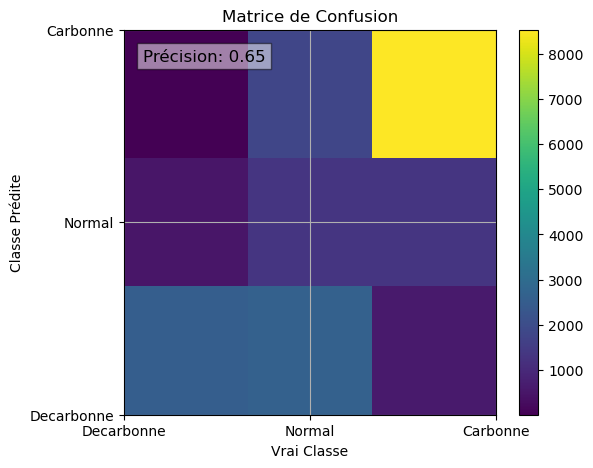

Accuracy 0.6454654373079127


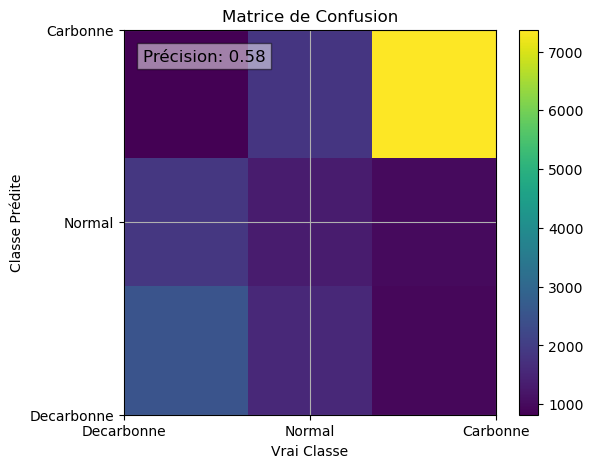

Accuracy 0.5836328593009324


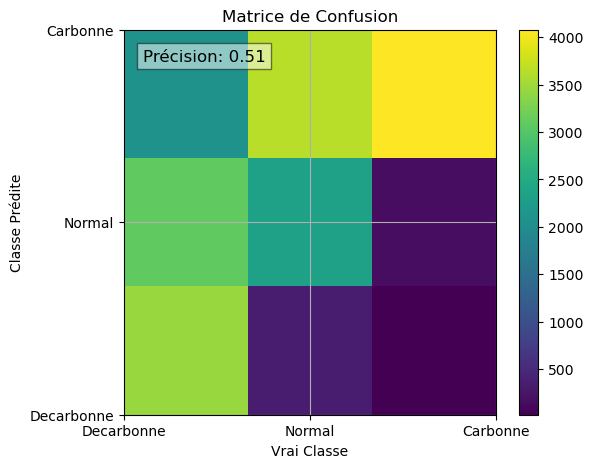

Accuracy 0.5146116580715737


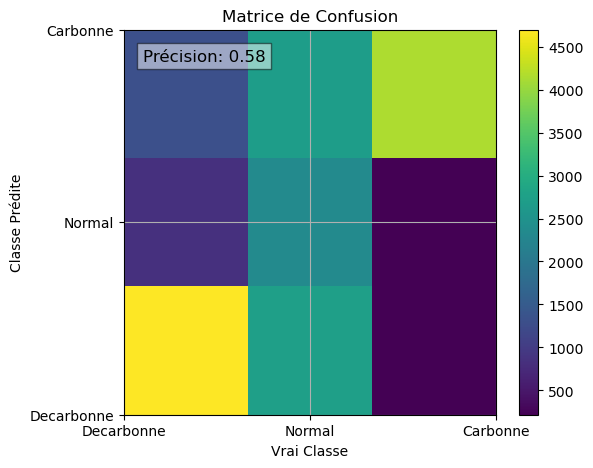

Accuracy 0.5826952127936657


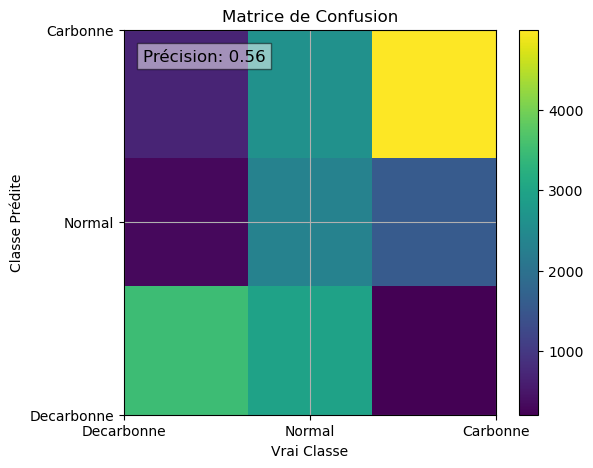

Accuracy 0.5636818252852008
Average: 0.5780173985518571, Deviation: 0.04202011390817586


In [20]:
def matrice_confusion(reverser, y_pred: np.ndarray, y_test: np.ndarray):
    """
    Retourne la précision de la prédiction et affiche la matrice de confusion

    Parameters:
    - reverser: Liste des classes
    - y_pred (np.ndarray): Classes prédites
    - y_test (np.ndarray): Vraie classes

    Returns:
    - accuracy (float): Taux de succès
    """
    accuracy = np.mean(y_test == y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    plt.hist2d(y_test, y_pred, bins=[3, 3])
    plt.title('Matrice de Confusion')
    plt.text(0.05, 0.95, f'Précision: {accuracy:.2f}', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
    plt.xticks(np.unique(y_test), reverser)
    plt.xlabel('Vrai Classe')
    plt.yticks(np.unique(y_pred), reverser)
    plt.ylabel('Classe Prédite')
    plt.grid(True)
    plt.colorbar()
    plt.show()
    plt.close()

    return accuracy

def rf_k_fold_pred(seed, features, k, hp) -> Tuple[float, float]:
    """
    Effectue K-Fold avec les FA

    Parameters:
        seed (int): Graine aléatoire
        features (list): Liste des variables à prendre en compte
        k (int): Nombre de partitions pour K-Fold
        hp (tuple): Tuple des hyperparamètres max_depth, min_samples_split, max_features et size

    Returns:
        stat (tuple): Tuple avec la précision et l'écart-type
    """

    print(f"SEED: {seed} | FOLDS: {k}")
    print(f"MAX_DEPTH: {hp[0]} | MIN_SPLIT: {hp[1]} | MAX_FEATURES: {hp[2]} | RF SIZE: {hp[3]}")
    print(f"FEATURES: {' '.join(features)}")

    np.random.seed(seed)

    data = load_data("train.csv")

    accuracies = []

    # K-Folds
    for i in range(k):
        # Fold
        data_train, data_test = k_fold(data, k ,i)
        x_train = data_train[features].values

        # Prep
        y_train = data_train["iMPE"].values
        x_test  = data_test[features].values
        y_test  = data_test["iMPE"].values
        reverser = np.array(["Decarbonne", "Normal", "Carbonne"])

        # Foret
        clsf = RandomForest(hp[2], hp[3], hp[0], hp[1])
        clsf.train(x_train, y_train)
        y_pred = clsf.predict(x_test)

        # Res
        accuracies.append(matrice_confusion(reverser, y_pred, y_test))

        for j in range(hp[3]):
            graph = clsf.graphe(features, clsf.vfeature_indices[j], j)
            graph.render(f"graphes/arbre_{i}_{j}", format='png', cleanup=True)

        print(f"Accuracy {accuracies[i]}")

    accuracy = np.mean(accuracies)
    deviation = np.std(accuracies)
    print(f"Average: {accuracy}, Deviation: {deviation}")
    return accuracy, deviation

accuracies = rf_k_fold_pred(
    # int(time.time()),
    1713975758,
    # Catégories non redondantes
    [
        "dPDA",
        "Annee",
        "iMois",
        "dHeure",
        "iJour",
        "dTemp",
        "dNebu",
        "dHumi",
        "dWind",
        "dRain",
    ],
    # K-Fold de 5 correspond à approximativement une année pour chaque fold
    5,
    # D'après une méthode itérative sur une fourchette controlée avec K-Fold
    [4, 2000, 4, 20])

In [ ]:
def recherche_hp(seed: int, features: list, k: int, hp_ranges: Tuple[range, range, range, range]) -> Tuple[float, float]:
    """
    Cherche les meilleurs hyperparamètres

    Parameters:
        seed (int): Graine
        features (list): Liste des noms de variables
        k (int): Partition K-Fold
        hp_ranges (Tuple[range, range, range, range]): Intevalles des hyperparamètres (max_depth, min_samples_split, max_features, size).

    Returns:
        best_accuracy (float): Meilleur précision
        best_deviation (float): Ecart Type des itération de K-Fold
        best_hyperparameters (Tuple): Tuple des 4 hyperparamètres
    """
    best_accuracy = 0.0
    best_deviation = float('inf')
    best_hyperparameters = None

    # Unpack hyperparameter ranges
    max_depth_range, min_samples_split_range, max_features_range, size_range = hp_ranges

    for max_depth in max_depth_range:
        for min_samples_split in min_samples_split_range:
            for max_features in max_features_range:
                for size in size_range:
                    accuracy, deviation = rf_k_fold_pred(seed, features, k, (max_depth, min_samples_split, max_features, size))

                    if accuracy > best_accuracy:
                        best_accuracy = accuracy
                        best_deviation = deviation
                        best_hyperparameters = (max_depth, min_samples_split, max_features, size)

                    elif accuracy == best_accuracy and deviation < best_deviation:
                        best_deviation = deviation
                        best_hyperparameters = (max_depth, min_samples_split, max_features, size)

    return best_accuracy, best_deviation, best_hyperparameters

recherche_hp(
    1713975758,
    [
        "dPDA",
        "Annee",
        "iMois",
        "dHeure",
        "iJour",
        "dTemp",
        "dNebu",
        "dHumi",
        "dWind",
        "dRain",
    ],
    5,
    # Profondeur 3-6, Echantillon minimum 2000-6000, Variables Max par arbre 3-5, Taille Foret
    (range(3, 6+1, 1), range(2000, 6000+2000, 2000), range(3, 5+1, 1), range(8, 20+4, 4)))

In [ ]:
def soumission():
    """
        Meme chose que rf_k_fold_pred mais sans paramètres ni sans k-fold ou affichage juste prédiction
    """
    seed = 1713975758
    features = [
        "dPDA",
        "Annee",
        "iMois",
        "dHeure",
        "iJour",
        "dTemp",
        "dNebu",
        "dHumi",
        "dWind",
        "dRain",
    ]
    hp = [4, 2000, 4, 20]

    np.random.seed(seed)

    data_train = load_data("train.csv")
    data_test = load_data("prev.csv", False)

    x_train = data_train[features].values
    y_train = data_train["iMPE"].values
    x_test = data_test[features].values

    clsf = RandomForest(hp[2], hp[3], hp[0], hp[1])
    clsf.train_parallel(x_train, y_train)
    y_pred = clsf.predict_parallel(x_test)

    for j in range(hp[3]):
        graph = clsf.graphe(features, clsf.vfeature_indices[j], j)
        graph.render(f"graphes/sarbre_{j}", format='png', cleanup=True)

    reverser = np.array(["Decarbonne", "Normal", "Carbonne"])
    str_y_pred = reverser[y_pred]

    ndf = data_test.copy()
    ndf["MixProdElec"] = str_y_pred
    filename = f"PREV_AD_FA_{'_'.join(features)}_{hp[0]}_{hp[1]}_{hp[2]}_{hp[3]}_{seed}.csv"
    ndf[["DateTime", "MixProdElec"]].to_csv(filename, index=False)

soumission()